# 04 — Final Test Analysis (the spine)

The conclusive notebook. Everything before this was decided on the **tuning** and
**robustness** samples; this is the one place the **untouched 1000-loan test set**
(`test_batch.csv`) is loaded and scored, exactly once.

**What it reports**, all on the held-out test set:
- **Performance** — AUC / F1 / recall on the *Charged Off* class, GPT-5.4 vs XGBoost.
- **Real financial P&L** — actual LendingClub cashflows (money in/out per loan), not
  made-up portfolio assumptions. A brief hypothetical-portfolio what-if is kept too.
- **Explainability** — SHAP attributions (XGBoost) next to GPT-5.4's natural-language rationale.
- **Error overlap** — do the two models fail on the same loans?

**Design decisions baked in:**
- **No threshold tuning.** Phase 1 (`01e`) showed GPT-5.4's logprobs are saturated
  (confidence ~0.96–0.99 whether right or wrong, conf-gap 0.03), so moving the decision
  threshold buys ~nothing. We report at the model's raw 0/1 output and say so.
- **Finalist = Phase-2 winning prompt × high reasoning effort** (`01d` found high best).
- **Load-if-exists everywhere** — the test set and the (expensive) LLM predictions are
  cached to disk; re-running this notebook loads them instead of spending API budget.


## Setup

In [1]:
import sys; sys.path.insert(0, '..')
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score)
from IPython.display import display

from llm_utils import (
    run_ml_on_sample, encode_for_ml, run_llm_experiment,
    build_user_prompt, format_loan_features, evaluate_predictions,
    DATA_DIR, RESULTS_DIR, MODEL_DIR,
)
from sample_generation import get_test_batch

load_dotenv('../.env', override=False)
MODEL   = 'gpt-5.4'
API_KEY = os.getenv('OPENAI_API_KEY')

# Extra keys widen throughput for the 1000-loan parallel run. Add OPENAI_API_KEY_2 /
# _3 to .env and they're picked up automatically; falls back to the single key.
from llm_utils import load_all_api_keys
API_KEYS = load_all_api_keys('openai')
MAX_WORKERS = max(1, len(API_KEYS) * 4)           # ~4 concurrent calls per key
print(f'{len(set(API_KEYS))} OpenAI key(s) -> {MAX_WORKERS} parallel workers')

FORCE_RERUN = False                              # True = re-call the API even if cached
PRED_PATH   = f'{RESULTS_DIR}/04_test_predictions.csv'
print('Cached predictions exist:', os.path.exists(PRED_PATH))

10 OpenAI key(s) -> 40 parallel workers
Cached predictions exist: True


## Step 1 — The held-out test set (load-if-exists)

Same pattern as the other samples: `get_test_batch()` returns the committed
1000-loan `test_batch.csv` if it exists, otherwise regenerates it deterministically
(seed 2024) from the held-out XGBoost test split — drawn from the **full** split
(no `desc` restriction) so it is representative of the real portfolio, and carrying
realized-cashflow columns for the financial analysis. Pass `force=True` to rebuild
from the raw file.

In [2]:
test   = get_test_batch()            # n=1000, require_desc=False, +cashflow cols
y_test = test['loan_status'].values
n_co   = int((y_test == 0).sum())
print(f'Test set: {len(test)} loans | Charged Off {n_co} ({n_co/len(test):.1%}) '
      f'| Fully Paid {len(test)-n_co}')
print('Realized-cashflow cols:',
      [c for c in ['funded_amnt','total_pymnt','total_rec_prncp','recoveries',
                   'collection_recovery_fee'] if c in test.columns])

Test set: 1000 loans | Charged Off 160 (16.0%) | Fully Paid 840
Realized-cashflow cols: ['funded_amnt', 'total_pymnt', 'total_rec_prncp', 'recoveries', 'collection_recovery_fee']


## Step 2 — Finalists

Phase 1 (`01d`) picked **`reasoning_effort='high'`**. Phase 2 (`02b`) F1/AUC leaders were
**`baseline`** (F1 0.387) and **`chain_of_thought`** (F1 0.370, AUC 0.645) — statistically
a tie at n=100. We run **both at high effort** on the 1000-loan test set and let the
larger sample adjudicate. Comment one out to run a single finalist.

(Prompts are lifted verbatim from `02b_Prompt_Variance.ipynb`. If they ever drift, the
clean fix is to move `PROMPT_VARIANTS` into a shared `prompt_variants.py` and import it
in both notebooks.)

In [3]:
_JSON_INSTRUCTION = (
    "\n\nRespond ONLY with valid JSON in this exact format:\n"
    '{"prediction": <1 or 0>, "reasoning": "<brief explanation>"}\n\n'
    "Where:\n"
    "- prediction: 1 = Fully Paid, 0 = Charged Off\n"
    "- reasoning: 1-2 sentence explanation of your prediction"
)

COT_SYSTEM = (
    "You are a credit risk analyst. "
    "Before predicting loan outcomes, reason step by step through the evidence. "
    "Identify the key risk signals, weigh them against protective factors, "
    "then arrive at a final prediction."
    + _JSON_INSTRUCTION.replace(
        "1-2 sentence explanation of your prediction",
        "step-by-step analysis: risk signals, protective factors, and conclusion",
    )
)

FINALISTS = [
    dict(name='baseline',
         system_prompt=None,            # None -> build_system_prompt()
         user_prompt_fn=None,           # None -> build_user_prompt(row, include_desc=False)
         reasoning_effort='high'),
    dict(name='chain_of_thought',
         system_prompt=COT_SYSTEM,
         user_prompt_fn=lambda row: (
             "Analyze this loan step by step and predict its outcome:\n\n"
             + format_loan_features(row, include_desc=False)),
         reasoning_effort='high'),
]
print('Finalists:', [f['name'] for f in FINALISTS])

Finalists: ['baseline', 'chain_of_thought']


## Step 3 — Run on the test set (the only cell that spends money)

`run_ml_on_sample` (XGBoost, free) + each finalist on GPT-5.4. Per-loan rows are cached to
`04_test_predictions.csv`; if that file exists and `FORCE_RERUN` is False we load it and
make **zero** API calls. At ~\$0.007/loan high-effort, a full run is ~\$7/finalist but
takes a while (1000 sequential reasoning calls) — let it run in the background once.

In [4]:
# Load-if-exists: if the predictions are already on disk and we're not forcing a
# rerun, load them and make ZERO API calls. This is the only cell that spends money,
# so re-running the notebook is free once the (expensive) test run has completed.
if os.path.exists(PRED_PATH) and not FORCE_RERUN:
    preds_df = pd.read_csv(PRED_PATH)
    print(f'Loaded cached predictions from {PRED_PATH} — no API calls.')
else:
    print('Running XGBoost (free) + finalists on GPT-5.4 (spends $).')
    rows = []

    xgb_probs, xgb_preds = run_ml_on_sample(test)
    for i in range(len(test)):
        rows.append(dict(model='XGBoost', loan_index=i, actual=int(y_test[i]),
                         prediction=int(xgb_preds[i]),
                         prob_fully_paid=float(xgb_probs[i]),
                         reasoning='', cost_usd=0.0))

    for f in FINALISTS:
        print(f"\n=== {f['name']} (high effort) on {len(test)} loans ===")
        r = run_llm_experiment(
            test, api_provider='openai', model_name=MODEL,
            api_keys=API_KEYS, max_workers=MAX_WORKERS,
            use_cache=not FORCE_RERUN,
            label=f"04 final | {f['name']}", include_desc=False, with_logprobs=True,
            system_prompt=f['system_prompt'], user_prompt_fn=f['user_prompt_fn'],
            reasoning_effort=f['reasoning_effort'],
            notebook_id='04_Final_Test_Analysis.ipynb',
            strict=True, max_fail_frac=0.2,
        )
        # Per-loan cost is returned by run_llm_experiment; embed it in the predictions
        # file so cost is derivable from predictions alone (no dependency on llm_calls.csv).
        cost = r.get('cost_usd') or [None] * len(test)
        for i, (p, prob, rea) in enumerate(
                zip(r['predictions'], r['probabilities'], r['reasonings'])):
            c = cost[i] if i < len(cost) else None
            rows.append(dict(model=f"GPT-5.4 ({f['name']})", loan_index=i,
                             actual=int(y_test[i]),
                             prediction=(int(p) if p is not None else np.nan),
                             prob_fully_paid=(float(prob) if prob is not None else np.nan),
                             reasoning=str(rea) if rea is not None else '',
                             cost_usd=(float(c) if c is not None else 0.0)))

    preds_df = pd.DataFrame(rows)
    preds_df.to_csv(PRED_PATH, index=False)

# Model list driving every downstream cell (Steps 4-6): XGBoost first, then each
# GPT-5.4 finalist, in insertion order.
models = list(preds_df['model'].unique())

display(preds_df.groupby('model').size())

Loaded cached predictions from /Users/alemz/Projects/Github/Sabadell_Capstone/data/results/llm/04_test_predictions.csv — no API calls.


model
GPT-5.4 (baseline)            1000
GPT-5.4 (chain_of_thought)    1000
XGBoost                       1000
dtype: int64

## Step 4 — Performance

AUC / F1 / precision / recall on the *Charged Off* class, at the raw 0/1 output (no
threshold tuning — see the intro). XGBoost test AUC ≈ 0.705 is the bar to clear.

In [5]:
def metrics_for(model_name):
    d = preds_df[preds_df['model'] == model_name].sort_values('loan_index')
    m = d['prediction'].notna()
    yt = d.loc[m, 'actual'].astype(int).values
    yp = d.loc[m, 'prediction'].astype(int).values
    # AUC over the rows that actually have a probability. LLM logprobs can be
    # sparse (or absent under high reasoning effort); one missing value shouldn't
    # void the whole AUC, so we compute it on the rows that do have a probability.
    prob = pd.to_numeric(d.loc[m, 'prob_fully_paid'], errors='coerce').values
    pm = ~np.isnan(prob)
    auc = (roc_auc_score(yt[pm], prob[pm])
           if pm.sum() >= 2 and len(np.unique(yt[pm])) == 2 else np.nan)
    return dict(model=model_name, n=int(m.sum()), n_auc=int(pm.sum()),
                accuracy=accuracy_score(yt, yp),
                precision_CO=precision_score(yt, yp, pos_label=0, zero_division=0),
                recall_CO=recall_score(yt, yp, pos_label=0, zero_division=0),
                f1_CO=f1_score(yt, yp, pos_label=0, zero_division=0),
                auc=auc)

perf = pd.DataFrame([metrics_for(m) for m in models]).set_index('model')
perf.to_csv(f'{RESULTS_DIR}/04_test_performance.csv')
display(perf.style.format({'accuracy': '{:.3f}', 'precision_CO': '{:.3f}',
                           'recall_CO': '{:.3f}', 'f1_CO': '{:.3f}', 'auc': '{:.3f}'},
                          na_rep='n/a'))

,n,n_auc,accuracy,precision_CO,recall_CO,f1_CO,auc
model,,,,,,,
XGBoost,1000,1000,0.688,0.279,0.600,0.381,0.706
GPT-5.4 (baseline),1000,0,0.764,0.284,0.312,0.298,n/a
GPT-5.4 (chain_of_thought),1000,0,0.775,0.270,0.237,0.252,n/a


## Step 5 — Real financial P&L (actual LendingClub cashflows)

The honest money question. For each loan we know the **realized** net cashflow to the
lender from the actual outcome:

```
net = total_pymnt + recoveries − collection_recovery_fee − funded_amnt
```

A model predicting **Fully Paid (1)** = *approve* (lender realizes that loan's actual net,
positive or negative); predicting **Charged Off (0)** = *reject* (capital not deployed, \$0).
Portfolio P&L = sum of realized net over approved loans. We compare each model against
**approve-everyone** and an **oracle** that approves only the loans that truly paid.

In [6]:
fund = test['funded_amnt'].fillna(test['loan_amnt'])
net  = (test['total_pymnt'].fillna(0)
        + test['recoveries'].fillna(0)
        - test['collection_recovery_fee'].fillna(0)
        - fund).values

def model_costs(model_name):
    """API $ for this model, summed from the per-loan cost embedded in the
    predictions file (XGBoost = 0). No dependency on llm_calls.csv."""
    d = preds_df[preds_df['model'] == model_name]
    if 'cost_usd' not in d.columns:
        return 0.0
    return float(pd.to_numeric(d['cost_usd'], errors='coerce').fillna(0).sum())

approve_all = net.sum()
oracle      = net[y_test == 1].sum()

rows = []
for m in models:
    d = preds_df[preds_df['model'] == m].sort_values('loan_index')
    approve = (d['prediction'] == 1).values
    realized = net[:len(approve)][approve].sum()
    api = model_costs(m)
    rows.append(dict(model=m, approved=int(approve.sum()),
                     realized_pnl=realized, api_cost=api,
                     net_after_api=realized - api))
rows.append(dict(model='Approve everyone', approved=len(net),
                 realized_pnl=approve_all, api_cost=0.0, net_after_api=approve_all))
rows.append(dict(model='Oracle (perfect)', approved=int((y_test == 1).sum()),
                 realized_pnl=oracle, api_cost=0.0, net_after_api=oracle))

pnl = pd.DataFrame(rows).set_index('model')
pnl['vs_approve_all'] = pnl['realized_pnl'] - approve_all
pnl.to_csv(f'{RESULTS_DIR}/04_test_financials.csv')
display(pnl.style.format({'realized_pnl': '${:,.0f}', 'api_cost': '${:,.2f}',
                          'net_after_api': '${:,.0f}', 'vs_approve_all': '${:,.0f}'}))
print('\nNote: API cost is ~5 orders of magnitude below the credit P&L — '
      'tokens are rounding error next to lending decisions (the 01f insight).')

,approved,realized_pnl,api_cost,net_after_api,vs_approve_all
model,,,,,
XGBoost,656,"$1,224,552",$0.00,"$1,224,552","$-850,500"
GPT-5.4 (baseline),824,"$1,652,007",$6.46,"$1,652,001","$-423,046"
GPT-5.4 (chain_of_thought),859,"$1,729,573",$11.35,"$1,729,562","$-345,479"
Approve everyone,1000,"$2,075,053",$0.00,"$2,075,053",$0
Oracle (perfect),840,"$2,765,903",$0.00,"$2,765,903","$690,850"



Note: API cost is ~5 orders of magnitude below the credit P&L — tokens are rounding error next to lending decisions (the 01f insight).


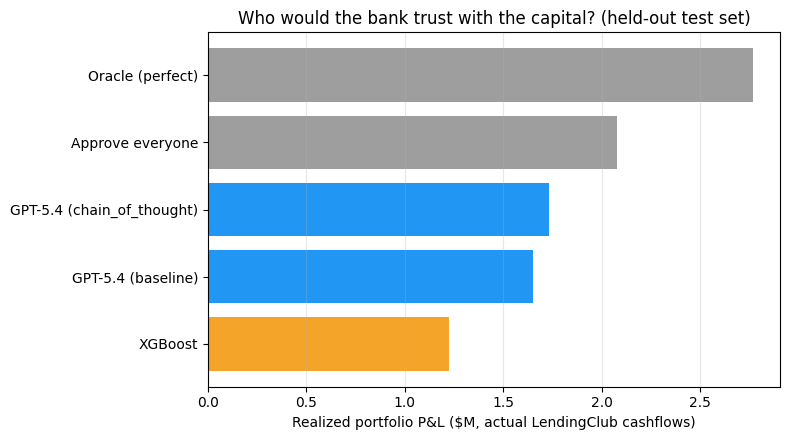

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = pnl['realized_pnl'].sort_values()
colors = ['#2196f3' if 'GPT' in m else '#9e9e9e' if m in
          ('Approve everyone', 'Oracle (perfect)') else '#f4a529' for m in order.index]
ax.barh(range(len(order)), order.values / 1e6, color=colors)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order.index)
ax.set_xlabel('Realized portfolio P&L ($M, actual LendingClub cashflows)')
ax.set_title('Who would the bank trust with the capital? (held-out test set)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/04_test_pnl.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5b — Case-by-case decision P&L (confusion-matrix costing)

A sharper money view than Step 5: every decision has a realized consequence,
**including the opportunity cost of turning away a good borrower**. Per loan,
from actual LendingClub cashflows:

| decision | actually Paid | actually Charged Off |
|---|---|---|
| **Approve** | `+ total_rec_int` (interest earned) | `total_pymnt + recoveries − collection_recovery_fee − funded_amnt` (realized loss) |
| **Reject**  | `− total_rec_int` (interest foregone) | `0` (loss avoided) |

Unlike Step 5 (where rejecting anything scores \$0), an **over-conservative model is
now penalised** for the good loans it declines. The oracle's P&L equals the total
interest income of the whole book — approve every good loan, decline every default.

In [8]:
# Case-by-case decision P&L: prices in the opportunity cost of rejecting good loans.
interest  = test['total_rec_int'].fillna(0).values
net_loss  = (test['total_pymnt'].fillna(0) + test['recoveries'].fillna(0)
             - test['collection_recovery_fee'].fillna(0)
             - test['funded_amnt'].fillna(test['loan_amnt'])).values

def case_pnl(pred):
    pred = np.asarray(pred).astype(int)
    ap = (pred == 1) & (y_test == 1)    # approve & paid    -> +interest
    ad = (pred == 1) & (y_test == 0)    # approve & default -> realized net_loss
    rp = (pred == 0) & (y_test == 1)    # reject  & paid    -> -interest (opportunity cost)
    # reject & default -> 0 (loss avoided)
    return dict(approve_paid_income=interest[ap].sum(),
                approve_default_loss=net_loss[ad].sum(),
                reject_paid_oppcost=-interest[rp].sum(),
                total_pnl=interest[ap].sum() + net_loss[ad].sum() - interest[rp].sum(),
                n_approved=int((pred == 1).sum()))

rows = []
for m in models:
    d = preds_df[preds_df['model'] == m].sort_values('loan_index')
    rows.append(dict(model=m, **case_pnl(d['prediction'].values)))
rows.append(dict(model='Approve everyone', **case_pnl(np.ones_like(y_test))))
rows.append(dict(model='Reject everyone',  **case_pnl(np.zeros_like(y_test))))
rows.append(dict(model='Oracle (perfect)', **case_pnl(y_test)))

casewise = pd.DataFrame(rows).set_index('model')
casewise.to_csv(f'{RESULTS_DIR}/04_test_pnl_casewise.csv')
_money = {c: '${:,.0f}' for c in casewise.columns if c != 'n_approved'}
display(casewise.style.format(_money, na_rep='n/a'))
print('\nRejecting a good borrower now costs the foregone interest, so an over-conservative '
      'model is penalised. Oracle = total interest income of the book.')

,approve_paid_income,approve_default_loss,reject_paid_oppcost,total_pnl,n_approved
model,,,,,
XGBoost,"$1,447,564","$-223,249","$-1,317,857","$-93,541",656
GPT-5.4 (baseline),"$2,112,585","$-460,902","$-652,836","$998,848",824
GPT-5.4 (chain_of_thought),"$2,224,721","$-495,502","$-540,699","$1,188,520",859
Approve everyone,"$2,765,421","$-690,850",$-0,"$2,074,571",1000
Reject everyone,$0,$0,"$-2,765,421","$-2,765,421",0
Oracle (perfect),"$2,765,421",$0,$-0,"$2,765,421",840



Rejecting a good borrower now costs the foregone interest, so an over-conservative model is penalised. Oracle = total interest income of the book.


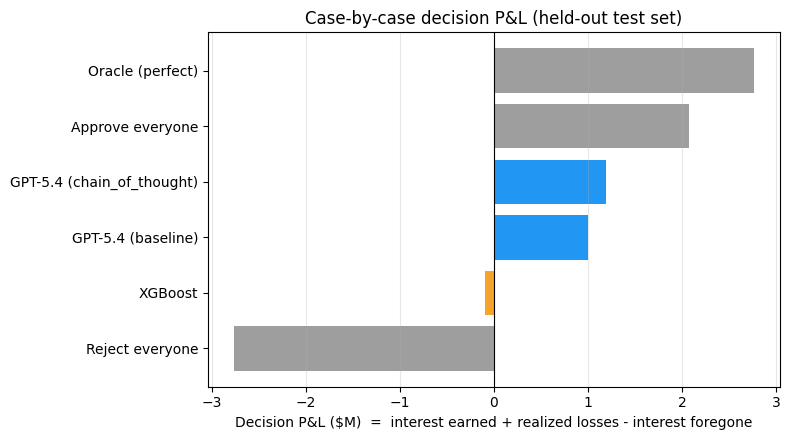

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = casewise['total_pnl'].sort_values()
base = ('Approve everyone', 'Reject everyone', 'Oracle (perfect)')
colors = ['#2196f3' if 'GPT' in m else '#9e9e9e' if m in base else '#f4a529' for m in order.index]
ax.barh(range(len(order)), order.values / 1e6, color=colors)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order.index)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Decision P&L ($M)  =  interest earned + realized losses - interest foregone')
ax.set_title('Case-by-case decision P&L (held-out test set)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/04_test_pnl_casewise.png', dpi=150, bbox_inches='tight')
plt.show()

### Brief: hypothetical-portfolio simulation (made-up assumptions)

Kept short for the deck's "scale this up" framing. Unlike Step 5, these are **not** real
dollars — they project each model's test-set error profile onto an illustrative
10k-loan book.

In [10]:
PORTFOLIO_SIZE = 10_000
AVG_LOAN       = 15_000
DEFAULT_RATE   = float((y_test == 0).mean())
LGD            = 0.65        # fraction of principal lost on a default
MARGIN         = 0.08        # net profit on a good loan

defaults  = PORTFOLIO_SIZE * DEFAULT_RATE
goods     = PORTFOLIO_SIZE - defaults
sim_rows  = []
for m in models:
    r = perf.loc[m]
    rec, prec = r['recall_CO'], r['precision_CO']
    tp = defaults * rec                       # defaults correctly rejected
    fn = defaults - tp                        # defaults wrongly approved -> loss
    fp = (tp / prec - tp) if prec > 0 else 0  # goods wrongly rejected -> lost profit
    loss_missed = fn * AVG_LOAN * LGD
    lost_profit = fp * AVG_LOAN * MARGIN
    sim_rows.append(dict(model=m, missed_default_loss=loss_missed,
                         lost_profit_rejections=lost_profit,
                         total_cost=loss_missed + lost_profit))
sim = pd.DataFrame(sim_rows).set_index('model')
display(sim.style.format('${:,.0f}'))

,missed_default_loss,lost_profit_rejections,total_cost
model,,,
XGBoost,"$6,240,000","$2,976,000","$9,216,000"
GPT-5.4 (baseline),"$10,725,000","$1,512,000","$12,237,000"
GPT-5.4 (chain_of_thought),"$11,895,000","$1,236,000","$13,131,000"


## Step 6 — Explainability: SHAP (XGBoost) vs LLM rationale

The brief's explainability comparison: XGBoost gives **quantitative per-feature SHAP
attributions**; GPT-5.4 gives a **natural-language rationale** for the same loan.

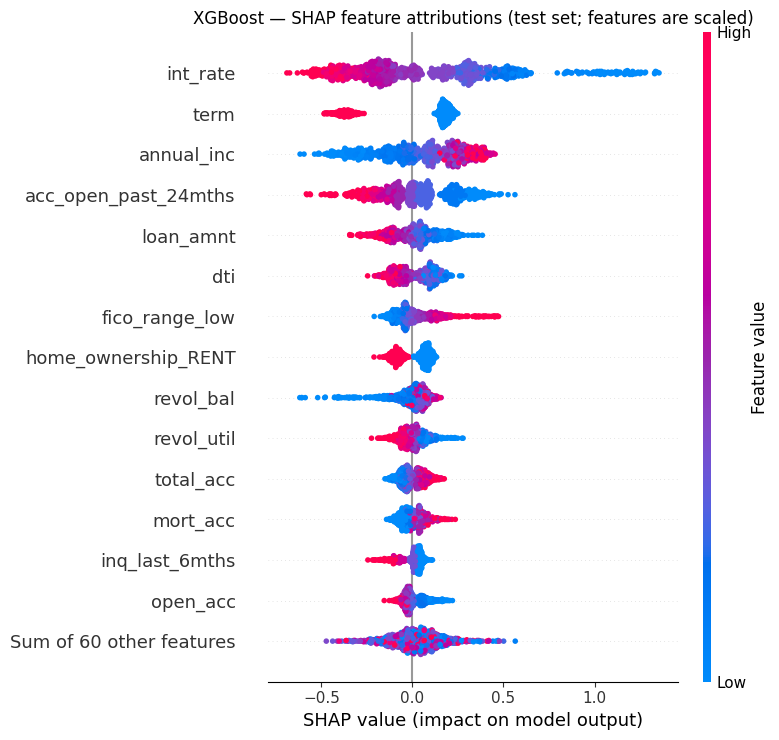

In [11]:
try:
    import shap
    X_test, xgb_model, _ = encode_for_ml(test)
    explainer = shap.TreeExplainer(xgb_model)
    sv = explainer(X_test)
    shap.plots.beeswarm(sv, max_display=15, show=False)
    plt.title('XGBoost — SHAP feature attributions (test set; features are scaled)')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/04_shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print('shap not installed — `pip install shap` to render the attribution plot.')

In [12]:
# GPT-5.4's rationale for loan 0 — the qualitative counterpart to the SHAP plot above.
llm_models_avail = [m for m in models if m.startswith('GPT')]
if llm_models_avail:
    ex = preds_df[preds_df['model'] == llm_models_avail[0]].sort_values('loan_index').iloc[0]
    print(f"Loan 0 | actual = {'Fully Paid' if ex['actual']==1 else 'Charged Off'} "
          f"| {llm_models_avail[0]} predicted "
          f"{'Fully Paid' if ex['prediction']==1 else 'Charged Off'}\n")
    print('Rationale:', ex['reasoning'])

Loan 0 | actual = Charged Off | GPT-5.4 (baseline) predicted Charged Off

Rationale: Despite the low DTI and long credit history, this application carries several strong default signals: a very high interest rate, a low LendingClub grade of F3, a large 60-month loan, and a recent delinquency. The middling FICO score and recent credit issues outweigh the otherwise stable income and employment profile.


## Step 7 — Error overlap

Do XGBoost and the best LLM finalist fail on the **same** loans? If they share most
errors, the dataset (not the model class) is the ceiling — the working hypothesis from
the progress report.

In [13]:
llm_best = perf.drop(index='XGBoost', errors='ignore')['f1_CO'].idxmax()
xgb = preds_df[preds_df['model'] == 'XGBoost'].set_index('loan_index')
llm = preds_df[preds_df['model'] == llm_best].set_index('loan_index')
j = xgb[['actual', 'prediction']].join(llm[['prediction']], rsuffix='_llm').dropna()

xgb_right = j['prediction'] == j['actual']
llm_right = j['prediction_llm'] == j['actual']
print(f'Head-to-head: XGBoost vs {llm_best}  (n={len(j)})')
print(f'  both right     : {(xgb_right & llm_right).sum()}')
print(f'  both wrong     : {(~xgb_right & ~llm_right).sum()}')
print(f'  XGBoost only   : {(xgb_right & ~llm_right).sum()}')
print(f'  LLM only       : {(~xgb_right & llm_right).sum()}')
co = j[j['actual'] == 0]
print(f'\nCharged Off loans (n={len(co)}): caught by XGBoost '
      f'{int((co["prediction"]==0).sum())}, by LLM {int((co["prediction_llm"]==0).sum())}, '
      f'by both {int(((co["prediction"]==0) & (co["prediction_llm"]==0)).sum())}')

Head-to-head: XGBoost vs GPT-5.4 (baseline)  (n=1000)
  both right     : 606
  both wrong     : 154
  XGBoost only   : 82
  LLM only       : 158

Charged Off loans (n=160): caught by XGBoost 96, by LLM 50, by both 41


## Verdict

One paragraph for the deck — fill in once the run completes:

- Headline: **AUC** (vs XGBoost ≈ 0.705) and **Charged Off F1** on the held-out 1000.
- **Money**: realized P&L vs approve-all and oracle — does the LLM's edge survive contact
  with real cashflows, and is the API cost (rounding error) worth it?
- **Explainability**: SHAP (quantitative, per-feature) vs LLM rationale (qualitative, readable).
- **Honest caveats**: GPT-5.4's saturated logprobs (no usable calibration / threshold lever),
  and how much of both models' error is shared (dataset ceiling).